# Evaluating footprints for various survey modes, in baseline survey v3 #

This notebook uses the input target footprint from the scheduler to describe the on-sky goal footprint for various survey modes.
Then MAF is used with the simulation output to describe the typical number of visits per filter in each of these areas. 

In [1]:
# Import required python modules
import os
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pandas as pd
import sqlite3
from astropy.coordinates import SkyCoord
import astropy.units as u
import rubin_scheduler.scheduler.utils as sched_utils
from rubin_scheduler.utils import ddf_locations
from rubin_sim.data import get_baseline
import rubin_sim.maf as maf

The survey 'target map' for baseline v3 is defined in the class [EuclidOverlapFootprint](https://rubin-scheduler.lsst.io/fbs-api-utils.html#rubin_scheduler.scheduler.utils.EuclidOverlapFootprint). 

In [2]:
nside = 64
sky = sched_utils.EuclidOverlapFootprint(nside=nside)
# footprints contains the goal weights per filter, for the sky (all survey modes together)
# labels contains the label (survey mode) for each healpix. 
footprints, labels = sky.return_maps()

In [3]:
# Each healpix is only labelled with a single survey mode label
np.unique(labels)

array(['', 'LMC_SMC', 'bulgy', 'dusty_plane', 'euclid_overlap', 'lowdust',
       'nes', 'scp', 'virgo'], dtype='<U20')

<Figure size 800x600 with 0 Axes>

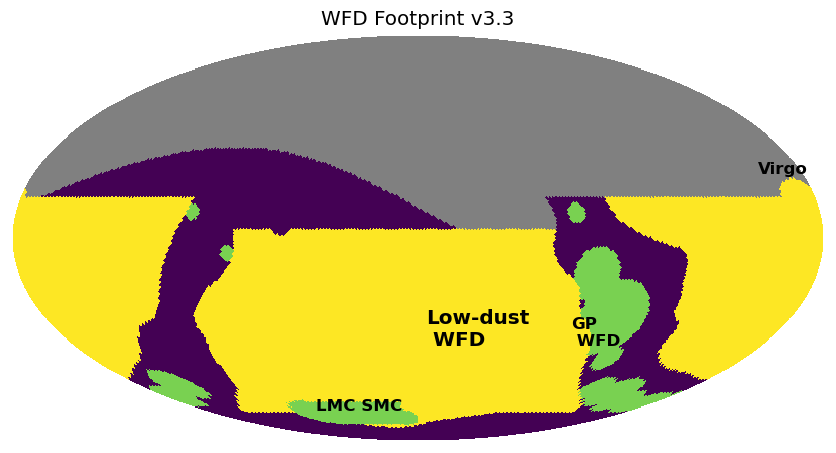

In [4]:
# Make a plot of the WFD-level coverage
pix = np.where((labels == "euclid_overlap") | (labels == "lowdust") |  (labels == "virgo"))
pix2 = np.where((labels == "LMC_SMC") | (labels == "bulgy"))
fp = np.zeros(hp.nside2npix(nside))
fp[pix] = 1
fp[pix2] = 0.8
fp[np.where(labels == "")] = hp.UNSEEN
plt.figure(figsize=(8, 6))
hp.mollview(fp, title=None, cbar=False)
plt.title("WFD Footprint v3.3", fontsize='x-large', fontweight='regular', color='black')
plt.figtext(0.51, 0.3, 'Low-dust\n WFD', fontsize='x-large', fontweight='bold', color='black')
#plt.figtext(0.31, 0.6, 'NES', fontsize='x-large', fontweight='bold', color='black')
plt.figtext(0.68, 0.3, 'GP\n WFD', fontsize='large', fontweight='bold', color='black')
plt.figtext(0.9, 0.62, "Virgo",  fontsize='large', fontweight='bold', color='black')
plt.figtext(0.38, 0.18, "LMC SMC", fontsize='large', fontweight='bold', color='black')
#plt.figtext(0.18, 0.4, 'Dusty\n Plane', fontsize='x-large', fontweight='bold', color='black')
#plt.figtext(0.55, 0.1, 'SCP', fontsize='x-large', fontweight='bold', color='black')
#plt.figtext(0.36, 0.3, 'DDFs', fontsize='x-large', fontweight='bold', color='black')
#hp.graticule()
plt.savefig('WFD_footprint.png', format='png')

In [5]:
# Total area in "WFD" above
pix2area = hp.nside2pixarea(nside, degrees=True)
len(np.where(fp > 0.7)[0]) * pix2area

19642.828472522146

<Figure size 800x600 with 0 Axes>

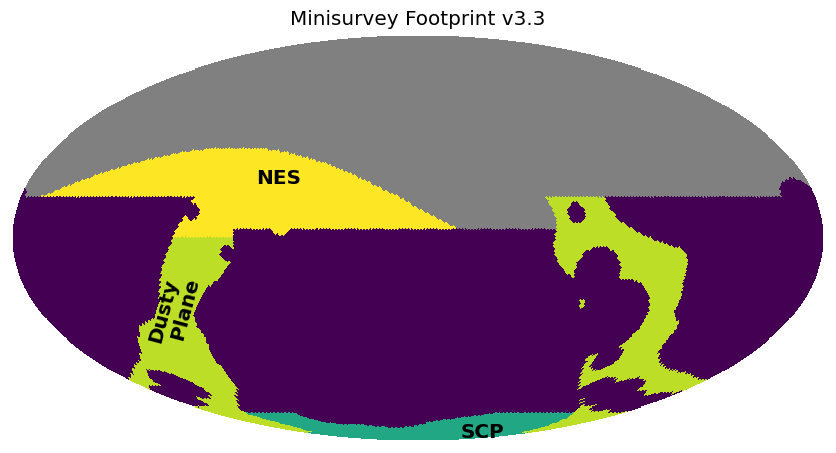

In [6]:
# Make a plot of the Minisurvey areas
fp = np.zeros(hp.nside2npix(nside))
fp[np.where(labels == "dusty_plane")] = 0.9
fp[np.where(labels == "nes")] = 1
fp[np.where(labels == "scp")] = 0.6
fp[np.where(labels == "")] = hp.UNSEEN
plt.figure(figsize=(8, 6))
hp.mollview(fp, title=None, cbar=False)
plt.title("Minisurvey Footprint v3.3", fontsize='x-large', fontweight='regular', color='black')
#plt.figtext(0.51, 0.3, 'Low-dust\n WFD', fontsize='x-large', fontweight='bold', color='black')
plt.figtext(0.31, 0.6, 'NES', fontsize='x-large', fontweight='bold', color='black')
#plt.figtext(0.68, 0.3, 'GP\n WFD', fontsize='large', fontweight='bold', color='black')
#plt.figtext(0.9, 0.62, "Virgo",  fontsize='large', fontweight='bold', color='black')
#plt.figtext(0.38, 0.18, "LMC SMC", fontsize='large', fontweight='bold', color='black')
plt.figtext(0.18, 0.3, 'Dusty\n Plane', rotation=75, fontsize='x-large', fontweight='bold', color='black')
plt.figtext(0.55, 0.13, 'SCP', fontsize='x-large', fontweight='bold', color='black')
#plt.figtext(0.36, 0.3, 'DDFs', fontsize='x-large', fontweight='bold', color='black')
#hp.graticule()
plt.savefig("Minisurvey_footprint.png", format="png")

In [7]:
# minisurvey areas
pix2area = hp.nside2pixarea(nside, degrees=True)
len(np.where(fp > 0.5)[0]) * pix2area

7534.339053060644

In [8]:
# Describe the DDF locations
ddfs = ddf_locations()
ddfs

{'ELAISS1': (9.45, -44.0),
 'XMM_LSS': (35.708333, -4.75),
 'ECDFS': (53.125, -28.1),
 'COSMOS': (150.1, 2.1819444444444445),
 'EDFS_a': (58.9, -49.315),
 'EDFS_b': (63.6, -47.6)}

In [9]:
pdfs = {}
for i in ddfs:
    ra = ddfs[i][0]
    dec = ddfs[i][1]
    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    eclip_lat = coord.barycentrictrueecliptic.lat.deg
    eclip_lon = coord.barycentrictrueecliptic.lon.deg
    gal_lon = coord.galactic.l.deg
    gal_lat = coord.galactic.b.deg
    pdfs[i] = [ra, dec, gal_lon, gal_lat, eclip_lon, eclip_lat]
pd.DataFrame(pdfs, index=['RA', 'Dec', 'Gal l', 'Gal b', 'Eclip l', 'Eclip b']).round(2)

,ELAISS1,XMM_LSS,ECDFS,COSMOS,EDFS_a,EDFS_b
RA,9.45,35.71,53.12,150.10,58.90,63.60
Dec,-44.00,-4.75,-28.10,2.18,-49.32,-47.60
Gal l,311.30,171.21,224.07,236.83,257.89,254.48
Gal b,-72.91,-58.77,-54.47,42.09,-48.46,-45.77
Eclip l,346.68,31.74,40.99,151.40,32.01,40.97
Eclip b,-43.18,-17.90,-45.47,-9.39,-66.60,-66.60


Query the database directly to see the "note" information, which describes the method in which different observations were acquired

In [10]:
conn = sqlite3.connect('baseline_v3.3_10yrs.db')

In [11]:
query = "select count(*) as cc, note from observations group by note"
d = pd.read_sql(query, conn)
d

,cc,note
0,40512,DD:COSMOS
1,22254,DD:ECDFS
2,11660,DD:EDFS_a
3,11597,DD:EDFS_b
4,20857,DD:ELAISS1
5,22286,DD:XMM_LSS
6,13294,"blob_long, gr, a"
7,10923,"blob_long, gr, b"
8,13148,"blob_long, iz, a"
9,11103,"blob_long, iz, b"


In [12]:
# Total number of visits and calculate fractional visits for each of the above modes
total = d.cc.sum()
d['fraction'] = d.cc/total* 100

In [13]:
# the "blob long" + long survey mode are the *triplet* visits 
blob_long_sum = d.query('note.str.contains("blob_long")').cc.sum()
blob_long_all = d.query('note.str.contains("long")').cc.sum()
blob_long_sum, blob_long_all, blob_long_all - blob_long_sum

(55778, 79175, 23397)

In [14]:
# The pairs are generally related to WFD, but also include pairs in the NES and galactic plane
# Pairs are acquired during relatively constant weather conditions, in 'regular' observing
allpairs = d.query('note.str.contains("pair")').cc.sum()

In [15]:
(blob_long_all - blob_long_sum) / ((allpairs + blob_long_sum)/2) * 100

2.5494287566672296

In [16]:
# Visits per DDF
d.query('note.str.contains("DD")')

,cc,note,fraction
0,40512,DD:COSMOS,1.901000
1,22254,DD:ECDFS,1.044255
2,11660,DD:EDFS_a,0.547138
3,11597,DD:EDFS_b,0.544182
4,20857,DD:ELAISS1,0.978701
5,22286,DD:XMM_LSS,1.045756


In [17]:
# Twilight NEO visit are for the near-sun twilight microsurvey
d.query('note.str.contains("twilight")').cc.sum()/2 / total * 100

1.4645563840834428

To evaluate the typical number of visits per pointing in each of the footprint areas above, it's relatively straightforward to calculate the number of visits per pointing (in all filters and per filter) and then use the healpix 'label' maps above to identify the relevant healpixels for each area. 

In [26]:
filterlist, colors, orders, sqls, info_labels = maf.batches.filter_list(all=True)
opsim_db = get_baseline()
opsim_name = os.path.split(opsim_db)[-1].replace('.db', '')
print('Running metrics on baseline run:', opsim_name)

Running metrics on baseline run: baseline_v3.3_10yrs


In [27]:
# Define the metric bundles
bundles = {}
nvisit_metric = maf.CountMetric(col='observationStartMJD', metric_name='NVisits')
coadd_metric = maf.Coaddm5Metric()
depth_metric = maf.MedianMetric(col='fiveSigmaDepth', metric_name='Median m5')
slicer = maf.HealpixSlicer(nside=nside)
for f in filterlist:
    bundles[f'nvisits_{f}'] = maf.MetricBundle(metric=nvisit_metric, 
                                  slicer=slicer, 
                                  constraint=sqls[f],
                                    run_name=opsim_name,
                                  info_label=info_labels[f],
                                  plot_dict={'color': colors[f], 'xlabel': 'N Visits'})
    bundles[f'coadd_{f}'] = maf.MetricBundle(metric=coadd_metric, 
                                  slicer=slicer, 
                                  constraint=sqls[f],
                                             run_name=opsim_name,
                                  info_label=info_labels[f],
                                  plot_dict={'color': colors[f], 'xlabel': 'Coadd m5'})
    bundles[f'visit_depth_{f}'] = maf.MetricBundle(metric=depth_metric,
                                  slicer=slicer, 
                                  constraint=sqls[f],
                                                   run_name=opsim_name,
                                  info_label=info_labels[f],
                                  plot_dict={'color': colors[f], 'xlabel': 'Median visit m5'})

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


In [28]:
# run the metrics 
out_dir = 'metric_data'
g = maf.MetricBundleGroup(bundles, opsim_db, out_dir=out_dir, results_db=None, verbose=True)
g.run_all()

Querying table None with no constraint for columns ['fieldDec', 'fiveSigmaDepth', 'observationStartMJD', 'fieldRA', 'rotSkyPos'].
Found 2130908 visits
Running:  ['nvisits_all', 'coadd_all', 'visit_depth_all']
Processing slices: 100%|███████████████| 49152/49152 [00:31<00:00, 1562.33it/s]
Completed metric generation.
Running reduce methods.
Running summary statistics.
Completed.
Querying table None with constraint filter = "z" for columns ['fieldDec', 'fiveSigmaDepth', 'observationStartMJD', 'fieldRA', 'rotSkyPos']
Found 436909 visits
Running:  ['nvisits_z', 'coadd_z', 'visit_depth_z']
Processing slices: 100%|███████████████| 49152/49152 [00:13<00:00, 3655.80it/s]
Completed metric generation.
Running reduce methods.
Running summary statistics.
Completed.
Querying table None with constraint filter = "u" for columns ['fieldDec', 'fiveSigmaDepth', 'observationStartMJD', 'fieldRA', 'rotSkyPos']
Found 123277 visits
Running:  ['nvisits_u', 'coadd_u', 'visit_depth_u']
Processing slices: 100%|█

1

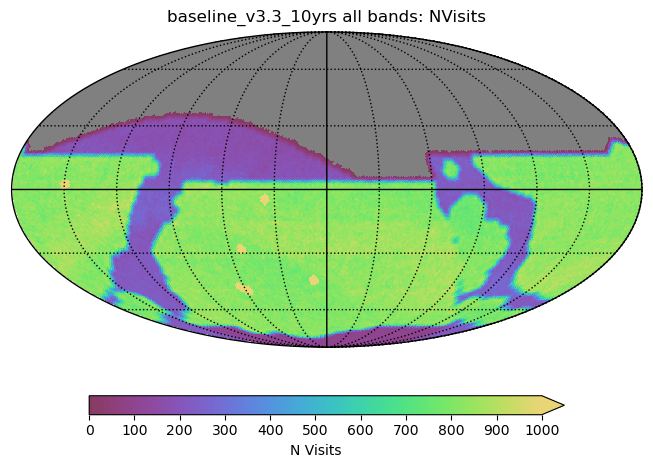

In [29]:
# Make a plot with the number of visits 
ph = maf.PlotHandler(out_dir=out_dir, fig_format='png', thumbnail=False)

ph.set_metric_bundles([bundles['nvisits_all']])
user_plot_dict = {'extend': 'max', 'color_min': 0, 'color_max': 1000}
ph.plot(maf.HealpixSkyMap(), plot_dicts=user_plot_dict)

So let's compare these metric results in some of the subsets of areas described up above .. low-dust WFD, GP WFD, NES, SCP, dusty plane. 

In [51]:
regions = [region for region in np.unique(labels) if len(region) > 0]
print(regions)

nvisits = {}
coadd_m5 = {}
visit_depth = {}
for region in regions:
    pix = np.where(labels == region)
    nvisits[region] = {}
    coadd_m5[region] = {}
    visit_depth[region] = {}
    for f in filterlist:
        nvisits[region][f] = np.median(bundles[f'nvisits_{f}'].metric_values.filled(0)[pix])
        coadd_m5[region][f] = np.median(bundles[f'coadd_{f}'].metric_values.filled(np.nan)[pix])
        visit_depth[region][f] = np.median(bundles[f'visit_depth_{f}'].metric_values.filled(np.nan)[pix])

['LMC_SMC', 'bulgy', 'dusty_plane', 'euclid_overlap', 'lowdust', 'nes', 'scp', 'virgo']


In [67]:
# Number of visits
nvis = pd.DataFrame(nvisits)
nvis

,LMC_SMC,bulgy,dusty_plane,euclid_overlap,lowdust,nes,scp,virgo
all,828.0,794.0,239.0,797.5,832.0,189.0,114.0,817.0
u,55.0,29.0,10.0,50.0,53.0,0.0,13.0,54.0
g,72.0,100.0,25.0,66.0,69.0,36.0,20.0,69.0
r,183.0,214.0,59.0,175.0,183.0,56.0,21.0,178.0
i,185.0,198.0,61.0,180.0,191.0,59.0,26.0,183.0
z,163.0,144.0,49.0,158.0,169.0,37.0,18.0,161.0
y,168.0,104.0,38.0,165.0,165.0,0.0,19.0,164.0


In [68]:
# Median single visit depth
single_m5 = pd.DataFrame(visit_depth)
single_m5.round(2)

,LMC_SMC,bulgy,dusty_plane,euclid_overlap,lowdust,nes,scp,virgo
all,23.18,23.51,23.38,23.00,23.33,23.39,23.04,23.04
u,23.01,23.14,23.26,22.91,23.21,NaN,22.82,22.84
g,24.28,24.46,24.57,24.19,24.49,24.13,24.12,24.18
r,23.95,24.05,24.06,23.83,24.09,23.77,23.73,23.81
i,23.43,23.56,23.52,23.23,23.59,23.21,23.13,23.30
z,22.85,22.95,22.90,22.68,22.98,22.61,22.65,22.68
y,21.87,22.00,22.03,21.71,22.05,NaN,21.67,21.65


In [69]:
# Coadded depth
coadd_m5 = pd.DataFrame(coadd_m5)
coadd_m5.round(2)

,LMC_SMC,bulgy,dusty_plane,euclid_overlap,lowdust,nes,scp,virgo
all,27.30,27.53,26.91,27.14,27.47,26.57,26.13,27.14
u,25.23,25.04,24.62,25.07,25.41,NaN,24.24,25.06
g,26.67,27.03,26.41,26.52,26.86,26.14,25.80,26.53
r,26.85,27.04,26.39,26.69,26.99,26.02,25.44,26.67
i,26.35,26.51,25.90,26.13,26.52,25.50,24.99,26.18
z,25.67,25.72,25.12,25.48,25.82,24.64,24.20,25.49
y,24.69,24.57,24.06,24.52,24.86,NaN,23.25,24.44


We could also plot just a single region of interest.

{'SkyMap': 1, 'Histogram': 2}

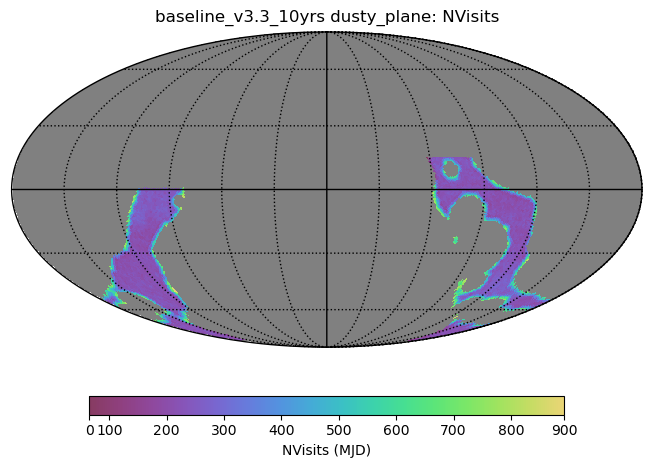

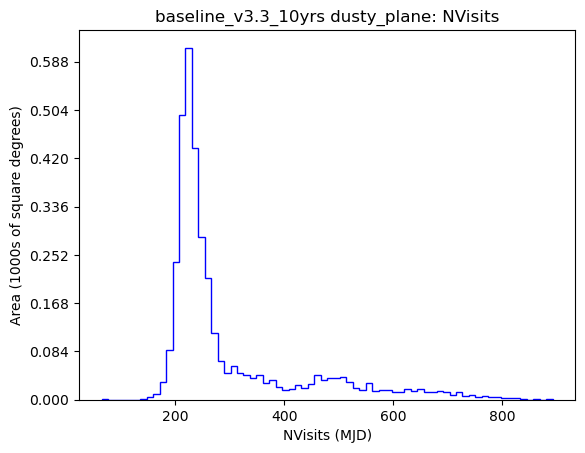

In [63]:
region = 'dusty_plane'
pix = np.where(labels == region, 1, 0)
data = bundles['nvisits_all'].metric_values.data * pix
# Let's make a temporary metric bundle, just so we can use the same plotting tools
temp_bundle = maf.MetricBundle(nvisit_metric, slicer, None, 
                               run_name=opsim_name,
                               info_label=region)
temp_bundle.metric_values = np.ma.MaskedArray(data=data, 
                                              mask=pix-1)
temp_bundle.plot()